# Practical session 4 - K-nearest neighbours (K-NN) classification with numpy, scikit-learn, cython and numba

Students (pair):
- [Henry Fernandes--Strag](https://github.com/hfstrag)
- [Alexandre Torres--Leguet]([link](https://github.com/alxndrTL))

GitHub project where we collaborate: https://github.com/alxndrTL/python_sdia

**Useful references for this lab**:

[1] scikit-learn: [documentation](https://scikit-learn.org/stable/modules/neighbors.html?highlight=knn%20classification)

[2] `numba`: [documentation](http://numba.pydata.org/) 

[3] cython: [a very useful tutorial](https://cython.readthedocs.io/en/latest/src/userguide/numpy_tutorial.html#numpy-tutorial), and [another one](http://docs.cython.org/en/latest/src/tutorial/cython_tutorial.html)



## <a name="content">Contents</a>
- [Exercise 1: KNN classification with numpy and sklearn](#ex1)
- [Exercise 2: Code acceleration with cython](#ex2)
- [Exercise 3: Code acceleration with numba](#ex3)
---

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import bottleneck as bn

## <a name="ex1">Exercise 1: K-Nearest Neighbours (K-NN) classification with numpy and scikit-learn</a> [(&#8593;)](#content)

This session is a first introduction to classification using the most intuitive non parametric method: the $K$-nearest neighbours. The principle is [the following](https://scikit-learn.org/stable/modules/neighbors.html?highlight=knn%20classification). A set of labelled observations is given as a learning set. A classification taks then consists in assigning a label to any new observation. In particular, the K-NN approach consists in assigning to the observation the most frequent label among its $K$ nearest neighbours taken in the training set.

### A. Validation on synthetic data

Load the training and test datasets `data/synth_train.txt` and `data/synth_test.txt`. Targets belong to the set $\{1,2\}$ and entries belong to $\mathbb{R}^2$. The file `data/synth_train.txt` contain 100 training data samples, and `data/synth_test.txt` contains 200 test samples, where:

- the 1st column contains the label of the class the sample;
- columns 2 & 3 contain the coordinates of each sample (in $\mathbb{R}^2$).

Useful commands can be found below.

```python
# load the training set
train = np.loadtxt('data/synth_train.txt')  #...,delimiter=',') if there are ',' as delimiters
class_train = train[:,0]
x_train = train[:,1:]
N_train = train.shape[0]
```

```python
# load the test set
test = np.loadtxt('/datasynth_test.txt') 
class_test_1 = test[test[:,0]==1]
class_test_2 = test[test[:,0]==2]
x_test = test[:,1:]
N_test = test.shape[0]
```

1\. Display the training set and distinguish the two classes. 

> Hint: useful functions include `matplotlib.pyplot.scatter` or `matplotlib.pyplot.plot`.

**Answer:**

In [3]:
# load the training set
train = np.loadtxt('data/synth_train.txt')
class_train = train[:,0]
x_train = train[:,1:]
N_train = train.shape[0]

# load the test set
test = np.loadtxt('data/synth_test.txt')
class_test = test[:,0]
class_test_1 = test[test[:,0]==1]
class_test_2 = test[test[:,0]==2]
x_test = test[:,1:]
N_test = test.shape[0]

Text(0.5, 1.0, 'Points du training set')

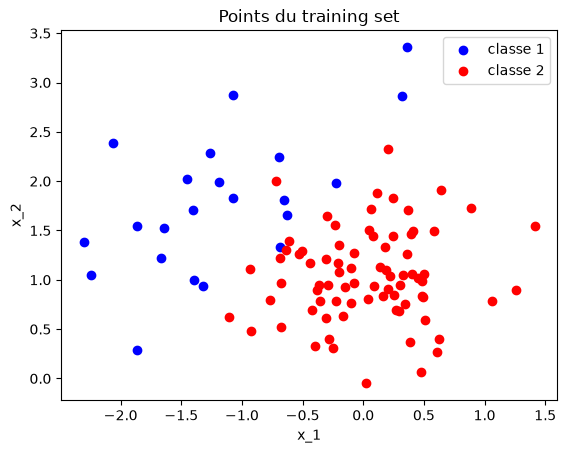

In [4]:
plt.scatter(x_train[class_train==1, 0], x_train[class_train==1, 1], color='blue', label='classe 1')
plt.scatter(x_train[class_train==2, 0], x_train[class_train==2, 1], color='red', label='classe 2')
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.legend()
plt.title('Points du training set')

2\. Implement the K-nearest neighbours algorithm for classification.

> Hint: 
> - useful functions include `numpy.linalg.norm`, `numpy.argsort`, `numpy.bincount`;
> - implement the algorithm as a function rather than an object. This will drastically simplify the acceleration step using Cython.
> - for an optimized partial sorting procedure, you may have a look at the [`bottleneck.argpartition` function](https://bottleneck.readthedocs.io/en/latest/reference.html#bottleneck.argpartition).
> 1. Compute for each row in `x_test` (if necessary use `np.newaxis`) its distance with respect to `x_train`:
>  - Use  `numpy.linalg.norm` (in which dimension this distance is computed ? Consider using `axis` argument)
> 2. Sort the ordered collection of distances (indices from smallest to largest (in ascending order) by the distances):
>   - Use `np.argsort` (at the end replace this procedure by `bottleneck.argpartition`)
>   - Once the sorting is done, we take only the indices of `labels` of the `n_neighbours` nearest neighbours of the `class_train` :
>     - `id = np.argsort(distances)[:n_ neighbours]` and `labels = class_train[id]`
> 3. The K-nearest can be used for **Regression**, in this case it is necessary to return the mean of the K-labels. For **Classification**,  we return the mode of the K-labels :
> - Use `np.bincount` for `labels` to affect the variable `class_pred[q]` (for row `q`). This procedure counts the number of occurrences of each value in array. **Mode** is the value that appears. How can we get this value ?


```python
import numpy as np
import bottleneck as bn

# Create a random array
arr = np.random.rand(10)
N = 3  # Number of smallest elements to retrieve

# Using np.argsort() to get indices of the first N elements
sorted_indices = np.argsort(arr)[:N]

# Using bottleneck.argpartition() to get the first N smallest indices
partitioned_indices = bn.argpartition(arr, N)[:N]

# Display the results
print("Original array:", arr)
print("Indices using np.argsort:", sorted_indices)
print("First N elements using np.argsort:", arr[sorted_indices])

print("Indices using bottleneck.argpartition:", partitioned_indices)
print("First N elements using bottleneck.argpartition:", arr[partitioned_indices])

are_equal = set(arr[sorted_indices]) == set(arr[partitioned_indices])
print(are_equal)
```


**Answer:**

In [5]:
# tests pour comprendre le fonctionnement de bottleneck.argpartition

l = np.array([11, 10, 14, 12, 13])

print('liste : ', l)
print('trié :', np.sort(l))

for k in range(len(l)):
    v = l[bn.argpartition(l, k)]
    print(k, v[:k])

# conclusion : bottleneck.argpartition(l, k)[:k+1] renvoie les indices des k+1 plus petits éléments de l (pas forcément dans l'ordre)
# c'est donc ce qu'on veut pour knn puisqu'on a seulement besoin de savoir quels sont les k plus proches points

liste :  [11 10 14 12 13]
trié : [10 11 12 13 14]
0 []
1 [10]
2 [11 10]
3 [11 10 12]
4 [11 10 13 12]


In [6]:
# tests pour comprendre bincount

print(np.bincount([0, 0, 1, 2, 1, 1, 2, 3]))

print(np.argmax(np.bincount([0, 0, 1, 2, 1, 1, 2, 3]))) # c'est bien la classe 1 la plus présente

# conclusion : bincount renvoie le nombre d'occurrences de chaque entier dans la liste, on fait un argmax dessus pour récuperer l'entier/la classe la plus présente

[2 3 2 1]
1


In [7]:
def knn(x_train, class_train, x_test, n_neighbours=3):
    """Algorithme des K plus proches voisins

    x_train      : (N_train, d)
    class_train  : (N_train,)
    x_test       : (N_test, d)
    n_neighbours : K
    Returns class_pred : (N_test,) predicted labels
    """

    class_train = class_train.astype(int)
    N_test = x_test.shape[0]
    class_pred = np.zeros(N_test, dtype=int)

    for q in range(N_test):
        # distance de "q" avec tous les points du training set
        # on calcule pour ça la norme de x_train-q, qui par broadcast correspond à la matrice
        # (x_train_1 - q, ..., x_train_N - q)
        # donc calculer la norme de chaque ligne de cette matrice nous donne les distances
        distances = np.linalg.norm(x_train - x_test[q], axis=1)

        # indices des K plus petites distances
        idx = bn.argpartition(distances, n_neighbours - 1)[:n_neighbours] # indices des K plus proches voisins
        labels = class_train[idx] # on récupère les labels de ces points voisins

        # vote majoritaire parmis "labels" = c'est notre prédiction
        class_pred[q] = np.argmax(np.bincount(labels))
        # (for regression you would return labels.mean() instead)

    return class_pred

3\. Compute the error rate on the training set and the test set for $K \in \{1,2, \dotsc, 20\}$. Display the classification result (see 1.) for the configuration with the lowest error rate.

**Answer:**

In [8]:
def accuracy(pred, truth):
    """Calcule l'exactitude des prédictions"""
    assert pred.shape == truth.shape, "le vecteur des prédictions doit avoir la même taille que le vecteur des étiquettes"
    return np.mean(pred == truth)

Ks = np.arange(1, 21)

accuracies_train = []
accuracies_test = []

for K in Ks:
    class_pred = knn(x_train, class_train, x_train, K)
    acc_train = accuracy(class_pred, class_train)

    class_pred = knn(x_train, class_train, x_test, K)
    acc_test = accuracy(class_pred, class_test)

    accuracies_train.append(acc_train)
    accuracies_test.append(acc_test)

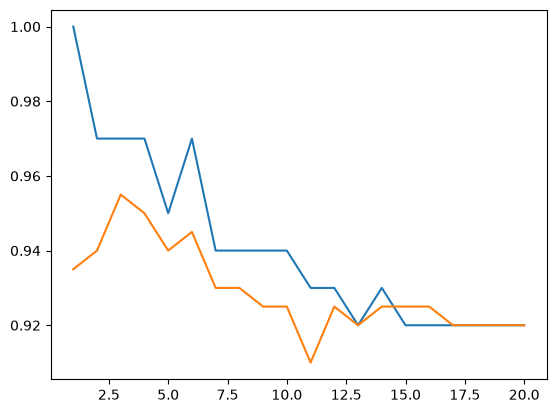

In [9]:
plt.plot(Ks, accuracies_train, label='train')
plt.plot(Ks, accuracies_test, label='test')

In [10]:
# la meilleure configuration pour le test set est avec K=3

In [11]:
# tests avec meshgrid pour plot le decision boundary (utilisé dans la cellule suivante)
# inspiré de la solution trouvée dans https://stackoverflow.com/questions/28256058/plotting-decision-boundary-of-logistic-regression

linspace1 = np.array([0,   1, 2])
linspace2 = np.array([10, 20, 30])

xx1, xx2 = np.meshgrid(linspace1, linspace2) # (N, N) x 2 : permet de quadriller l'espace x1-x2 avec N*N points
print(xx1) # coordonnées x1 des points du quadrillage
print(xx2) # coordonnées x2 des points du quadrillage

print(xx1.flatten())
print(xx2.flatten())

print(np.column_stack([xx1.flatten(), xx2.flatten()])) # permet de reconstituer (x1, x2) des points du quadrillage

[[0 1 2]
 [0 1 2]
 [0 1 2]]
[[10 10 10]
 [20 20 20]
 [30 30 30]]
[0 1 2 0 1 2 0 1 2]
[10 10 10 20 20 20 30 30 30]
[[ 0 10]
 [ 1 10]
 [ 2 10]
 [ 0 20]
 [ 1 20]
 [ 2 20]
 [ 0 30]
 [ 1 30]
 [ 2 30]]


Text(0.5, 1.0, 'Points du training set et zone de décision pour K=3 (accuracy test=0.95)')

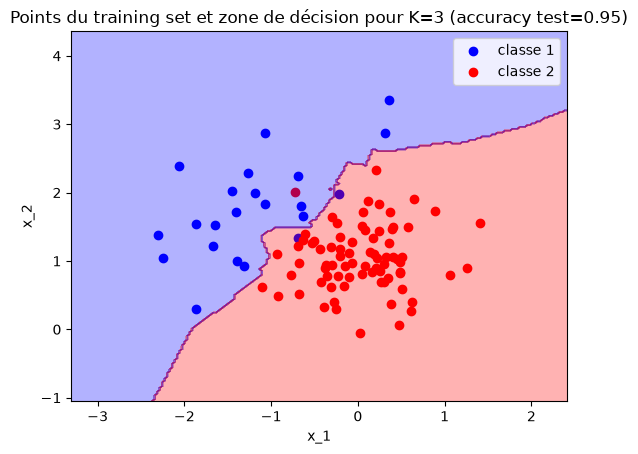

In [12]:
# on plot le decision boundary pour K=3
K = 3
class_pred = knn(x_train, class_train, x_test, K)
acc_test = accuracy(class_pred, class_test)

# affichage des points du dataset
plt.scatter(x_train[class_train==1, 0], x_train[class_train==1, 1], color='blue', label='classe 1')
plt.scatter(x_train[class_train==2, 0], x_train[class_train==2, 1], color='red', label='classe 2')

# affichage du decision boundary
N = 200
linspace1 = np.linspace(x_train[:,0].min()-1, x_train[:,0].max()+1, N) # (N,) : linspace pour x1
linspace2 = np.linspace(x_train[:,1].min()-1, x_train[:,1].max()+1, N) # (N,) : linspace pour x2
xx1, xx2 = np.meshgrid(linspace1, linspace2) # (N, N) x 2 : permet de quadriller l'espace x1-x2 avec N*N points

Z = knn(x_train, class_train, np.column_stack([xx1.flatten(), xx2.flatten()]), K).reshape(xx1.shape)

plt.contourf(xx1, xx2, Z, alpha=0.3, colors=['blue', 'red'])

plt.xlabel('x_1')
plt.ylabel('x_2')
plt.legend()
plt.title(f'Points du training set et zone de décision pour K={K} (accuracy test={acc_test:.2f})')

4\. Comment on your results. Which value of $K$ seems optimal ?


**Answer:**

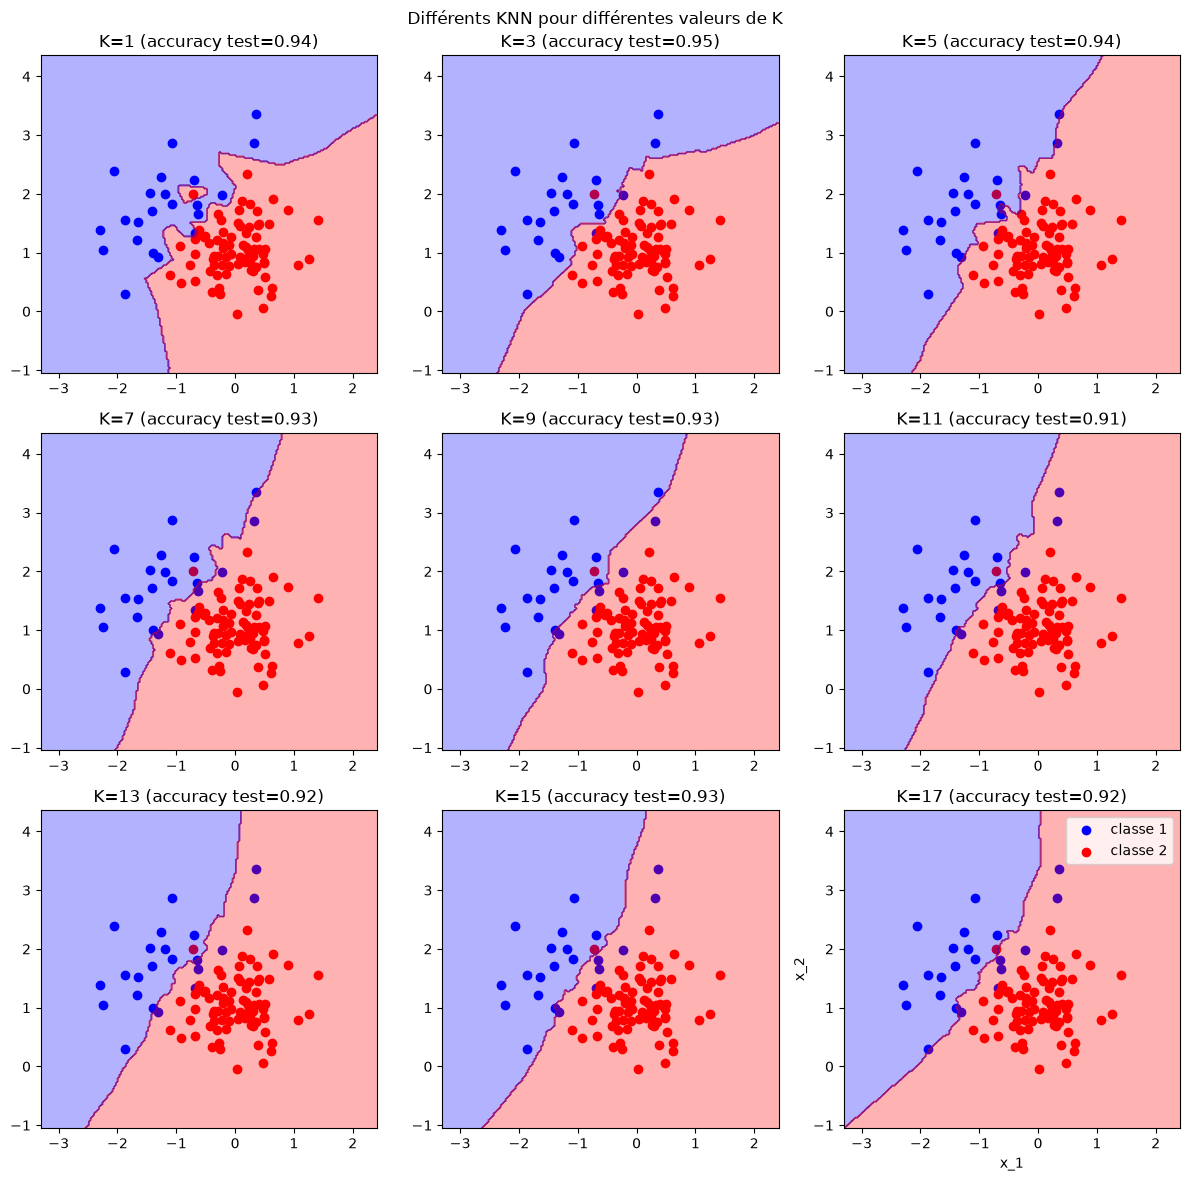

In [13]:
# on répète le plot précédent pour différentes valeurs de K, pour voir son influence sur la prédiction du modèle
# pour cela, on l'englobe dans une boucle (une pour chaque valeur de K testée) et on affiche les résultats dans une grille de sous-figures

Ks = np.arange(1, 19, 2) # les K qu'on teste
fig, axes = plt.subplots(3, 3, figsize=(12, 12)) # les 3x3 sous-figures

# code commun déplacé hors de la boucle
N = 200
linspace1 = np.linspace(x_train[:,0].min()-1, x_train[:,0].max()+1, N) # (N,) : linspace pour x1
linspace2 = np.linspace(x_train[:,1].min()-1, x_train[:,1].max()+1, N) # (N,) : linspace pour x2
xx1, xx2 = np.meshgrid(linspace1, linspace2) # (N, N) x 2 : permet de quadriller l'espace x1-x2 avec N*N points

for ax, K in zip(axes.flat, Ks):
    class_pred = knn(x_train, class_train, x_test, K)
    acc_test = accuracy(class_pred, class_test)

    # affichage des points du dataset
    ax.scatter(x_train[class_train==1, 0], x_train[class_train==1, 1], color='blue', label='classe 1')
    ax.scatter(x_train[class_train==2, 0], x_train[class_train==2, 1], color='red', label='classe 2')

    # affichage du decision boundary
    Z = knn(x_train, class_train, np.column_stack([xx1.flatten(), xx2.flatten()]), K).reshape(xx1.shape)

    ax.contourf(xx1, xx2, Z, alpha=0.3, colors=['blue', 'red'])

    ax.set_title(f'K={K} (accuracy test={acc_test:.2f})')

plt.xlabel('x_1')
plt.ylabel('x_2')
plt.legend()
fig.suptitle(f'Différents KNN pour différentes valeurs de K')
plt.tight_layout()

La valeur de K optimale semble être 3 (cf graphique de la question précédente). Ici, on visualise les prédictions des différents KNN en fonction de K. Un K petit (typiquement 1) possède un faible biais mais une haute variance : il y a sur-apprentissage. Donc les performances sur les données tests sont moins bonnes (le modèle généralise moins bien). Au contraire, une haute valeur de K réduit la variance mais augmente le biais : le modèle rate même la classification de points du training set. Le bon compromis est trouvé pour K=3.

On note qu'en pratique, on pourrait estimer le meilleur K grâce à une méthode de cross-validation (qui divise le training set en plusieurs validation set et training sets). Sinon, estimer le K avec les données de tests constitue une fuite de données.

5\. Compare the results of you implementation with those of [`sklearn.neighbors.KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html?highlight=kneighborsclassifier#sklearn.neighbors.KNeighborsClassifier). Compare the runtime of these two versions using the [`timeit`](https://docs.python.org/3/library/timeit.html) module (see session 1).

**Answer:**

In [14]:
from sklearn.neighbors import KNeighborsClassifier

K = 3

# équivalence numérique avec notre version
knn_sklearn = KNeighborsClassifier(n_neighbors=K)
knn_sklearn.fit(x_train, class_train)

print("score knn de sklearn :")
print(knn_sklearn.score(x_test, class_test))

class_pred = knn(x_train, class_train, x_test, K)
acc_test = accuracy(class_pred, class_test)
print("score de notre propre knn :")
print(acc_test)

score knn de sklearn :
0.955
score de notre propre knn :
0.955


In [15]:
# performance
print("Runtime de notre knn :")
%timeit knn(x_train, class_train, x_test, 3)

print("Runtime de knn de sklearn :")
%timeit knn_sklearn.fit(x_train, class_train); knn_sklearn.predict(x_test)

Runtime de notre knn :
831 μs ± 39.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Runtime de knn de sklearn :
561 μs ± 15.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [16]:
# avec des datasets plus grands:
N = 10000
X_train = np.random.rand(N, 2)
y_train = np.random.randint(0, 2, N)
X_test = np.random.rand(N, 2)

%timeit knn(X_train, y_train, X_test, 3)
%timeit knn_sklearn.fit(X_train, y_train); knn_sklearn.predict(X_test)

1.63 s ± 65.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
8.45 ms ± 157 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


En terme de qualité, on retrouve bien, pour K=3, la même performance sur les données test que notre implémentation.

En terme de rapidité en revanche, la solution de scikit-learn est environ 2x plus rapide que notre version pour des petits datasets. Pour des datasets plus gros (10 000 exemples), l'écart est encore plus grand avec notre version.

### B. Application to a real dataset (Breast cancer Wisconsin).

6\. Apply the K-NN classifier to the real dataset `data/wdbc12.data.txt.` Further details about the data are provided in `data/wdbc12.names.txt`.

> Hint: you can use the function [`train_test_split` from `sklearn.model_selection`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) to split the dataset into a training and a test set.

**Answer:**

In [17]:
# load the training set
dataset = np.loadtxt('data/wdbc12.data.txt', delimiter=',')

# l'attribut 0 est un ID, qui n'est pas une feature donc on l'exclue
# on récupère la classe (sain / malade) en attribut 1
# le reste = les features
y = dataset[:,1]
X = dataset[:,2:]
N = dataset.shape[0]

print(X.shape, y.shape) # 569 exemples, en dimension 30, avec 2 classes (sain / malade)

(569, 30) (569,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

# nombre de positifs et négatifs dans le training set
print("nombre de positifs : ", np.sum(y_train==1))
print("nombre de négatifs : ", np.sum(y_train==2))

(455, 30) (455,)
(114, 30) (114,)
nombre de positifs :  169
nombre de négatifs :  286


In [19]:
K = 11 # trouvée par tatonnement

y_pred = knn(X_train, y_train, X_train, K)
acc_train = accuracy(y_pred, y_train)

y_pred = knn(X_train, y_train, X_test, K)
acc_test = accuracy(y_pred, y_test)

print(f"accuracy train : {acc_train:.2f}")
print(f"accuracy test : {acc_test:.2f}")

accuracy train : 0.93
accuracy test : 0.98


On obtient une accuracy de 98% sur les données tests. Cela veut dire qu'on arrive à prédire correctement dans 98% si une tumeur est bénigne ou maligne. Ce nombre n'est pas à comparer avec 50% car dans ce cas, le dataset n'est pas équilibré (il est composé à 63% de tumeurs bénignes). Donc un predicteur aléatoire qui prédit toujours "bénin" obtiendrait 63% et non 50%. 98% reste donc un bon score.

## <a name="ex2">Exercise 2: Code acceleration with cython</a> [(&#8593;)](#content)

Cython allows C code to be easily interfaced with Python. It can be useful to make your code faster for a small coding effort, in particular when using loops. A general approach to optimize your code is outlined in the [Scipy lecture notes, Section 2.4](https://scipy-lectures.org/advanced/optimizing/index.html). Complementary reading about interfacing Python with C can be found in [Section 2.8](https://scipy-lectures.org/advanced/interfacing_with_c/interfacing_with_c.html).

1\. Read carefully the [cython tutorial](http://docs.cython.org/en/latest/src/tutorial/cython_tutorial.html), which describes step by the step how the toy example reported below has been developed.

**Setup**: Compile the toy example provided in `example_cy/` by running, in the command line (anaconda prompt on windows)

```bash
cd example_cy && python setup.py build_ext --inplace
```

Note that the compilation process has been slightly automatised with the instructions reported in `example_cy/setup.py`. To test the module, run

In [20]:
import sys
print(sys.executable)
print(sys.version)

!cd example_cy && python setup.py build_ext --inplace

/Users/alexandre/Desktop/inge/G3/python/.venv/bin/python
3.14.5 (main, May 10 2026, 10:21:34) [Clang 21.0.0 (clang-2100.0.123.102)]
running build_ext


In [21]:
import example_cy.helloworld as toy

toy.printhello()

Hello World


which should display
```python
Hello World
```

> Warning: 
> - do not forget to include an empty `__init__.py` file in the directory where your source code lives (`import` will fail if this is not the case).
> - in case you have any setup issue, take a look at the `notes.md` file.
> - if the C code and/or the executable do not seem to be regenerated by the build instructions, delete the C code and the executable first, and re-execute the compilation afterwards.
> - do not hesitate to restart the Python kernel if necessary when the Cython executable has been re-generated.

2\. Read the [Numpy/Cython tutorial](https://cython.readthedocs.io/en/latest/src/userguide/numpy_tutorial.html#numpy-tutorial), focussing on the paragraphs **Cython at a glance**, and **Your Cython environment** until **"More generic code"**. An example to compile a `.pyx` file depending on `numpy` is included in `example_np_cy/`.

> Remarks: 
> - the `annotate=True` flag in the `setup.py` allows an additional `.html` document to be generated (`<your_module_name>.html`), showing, for each line of the Cython code, the associated C instructions generated. Highlighted in yellow are the interactions with Python: the darker a region appears, the less efficient the generated C code is for this section. Work in priority on these! 
> - make sure all the previously generated files are deleted to allow the .html report to be generated;
> - if you are working on your own machine and don't have a C/C++ compiler installed, read the notes provided in `notes.md`;
> - use `cdef` for pure C functions (not exported to Python), `cpdef` should be favored for functions containing C instructions and later called from Python.

**Answer:**

In [22]:
!cd example_np_cy && python setup.py build_ext --inplace

In [23]:
%load_ext Cython

Exemple simple pour tester Cython (issu de la doc) :

In [24]:
%%cython -a
def somme_carres(int n):
    cdef long total = 0
    cdef int i
    for i in range(n):
        total += i * i
    return total

In [25]:
def somme_py(n):
    total = 0
    for i in range(n):
        total += i * i
    return total


%timeit somme_py(10_000_000)
%timeit somme_carres(10_000_000)

345 ms ± 31.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.48 ms ± 220 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Sur cet exemple on voit bien la différence de perf

3\. Use Cython to implement a faster version of the numpy K-NN classifier implemented in [Exercise 1](#ex1). To do so, apply step-by-step the techniques introduced in the [Numpy/Cython tutorial](https://cython.readthedocs.io/en/latest/src/userguide/numpy_tutorial.html#numpy-tutorial) (*i.e.*, compile and time your code after each step to report the evolution, keeping track of the different versions of the cython function).

> Hint: if you keep numpy arrays, make sure you use memory views (see numpy/cython tutorial) to access the elements within it. Be extremely careful with the type of the input arrays (you may need to recast the format of the input elements before entering the function. The `numpy.asarray` function can prove useful).

> **Detailed guidelines**: a few notes and *caveat* to help you re-writing your code in cython:
> - try to reduce the number of calls to numpy instructions as much as possible;
> - **you do not have to optimize everything**. For the KNN function above, most of the time is spent in computing euclidean distances: you can thus focus on optimizing tihs operations by explicitly writing a for loop, which will ensure a minimal interaction with numpy when generating the associated C code at compilation. Calls to other numpy functions can be kept as-is;
> - if you need to create an array within the cython function, used np.zeros (**do NOT use python lists**), and use a memory view to access its content;
> - specify the type for all variables and numpy arrays. Pay attention to the type of the input arrays passed to the Cython function;
> - whenever an array is returned, use memory views and index(es) to efficiently access its content;
> - some numpy operators (e.g., broadcasting mechanism) do not work with memory views. In this case, you can directly write for loop(s) to encode the operation of interest (the loops will be optimized out at compile time);
> - only use at the final development stage the following cython optimization (not before, as they can crash the program without any help):
>
>```python
>@cython.boundscheck(False)
>@cython.wraparound(False)
>```

**Answer:**

On part de la version NumPy de l'exercice 1,
puis on applique de nouvelles techniques une par une, en **compilant et chronométrant à chaque étape**

In [26]:
#Rappel du code original :
import numpy as np
import bottleneck as bn
import time

#on prend un dataset synthétique avec beaucoup de données pour mieux évaluer les performances de nos différentes versions à venir.

K = 3
N = 1000
X_train = np.random.rand(N, 2)
y_train = np.random.randint(0, 2, N)
X_test = np.random.rand(N, 2)

knn_sklearn = KNeighborsClassifier(n_neighbors=K)

def Knearest_neighbours(x_test, x_train, class_train, K):
    class_train = class_train.ravel().astype(int)
    class_pred = np.zeros((x_test.shape[0], 1), dtype=int)
    for i, row in enumerate(x_test):
        distances = np.linalg.norm(row - x_train, axis=1)
        indice_nearest = bn.argpartition(distances, K)[:K]
        labels = class_train[indice_nearest]
        vote = np.bincount(labels)
        class_pred[i] = np.argmax(vote)
    return class_pred

Les memory views Cython exigent des types précis : float64 contigu pour les données,
int64 pour les labels, donc on les convertit ici une fois pour toutes.

In [27]:
xt = np.ascontiguousarray(X_test, dtype=np.float64)
xtr = np.ascontiguousarray(X_train, dtype=np.float64)
ct = np.ascontiguousarray(y_train.ravel(), dtype=np.int64)

#pour comparer les gains en temps de chaque version :
def bench(f, n=100):
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        res = f(xt, xtr, ct, K)
        times.append(time.perf_counter() - t0)
    return np.median(times), res


## Référence NumPy : 

In [28]:

results = {}   # nom -> temps (s)
t, ref = bench(Knearest_neighbours)
results['numpy'] = t
print(f"numpy : {t:.4f} s")

numpy : 0.0192 s


## V1 : code Python compilé tel quel

On reprend le code Python sans modification : on mesure le gain apporté par la seule compilation.
Tout reste jaune car chaque opération passe par l'interpréteur Python.

In [29]:
%%cython -a
import numpy as np
import bottleneck as bn

def knn_v1(x_test, x_train, class_train, K):
    class_train = class_train.ravel().astype(int)
    class_pred = np.zeros((x_test.shape[0], 1), dtype=int)
    for i, row in enumerate(x_test):
        distances = np.linalg.norm(row - x_train, axis=1)
        indice_nearest = bn.argpartition(distances, K)[:K]
        labels = class_train[indice_nearest]
        vote = np.bincount(labels)
        class_pred[i] = np.argmax(vote)
    return class_pred

In [30]:
t, res = bench(knn_v1)
assert np.array_equal(res, ref)
results['v1'] = t
print(f"v1 : {t:.4f} s")

v1 : 0.0168 s


## V2 : types C, memory views et boucle explicite

- les entrées sont typées en memory views (`double[:, ::1]`, `long long[::1]`)
- les indices et accumulateurs sont déclarés avec `cdef`
- `np.linalg.norm(row - x_train, axis=1)` (qui crée un tableau temporaire à chaque ligne de test)
  est remplacé par deux boucles `for`
- `distances` est créé avec `np.zeros` et accédé via une memory view
- `argpartition`, `bincount` et `argmax` restent en numpy

In [31]:
%%cython -a
import numpy as np
import bottleneck as bn

def knn_v2(double[:, ::1] x_test, double[:, ::1] x_train,
           long long[::1] class_train, int K):

    cdef Py_ssize_t n_test = x_test.shape[0]
    cdef Py_ssize_t n_train = x_train.shape[0]
    cdef Py_ssize_t n_feat = x_test.shape[1]
    cdef Py_ssize_t i, j, k
    cdef double s, diff
    cdef long long[:, ::1] pred_view

    distances = np.zeros(n_train, dtype=np.float64)
    cdef double[::1] dist_view = distances
    class_pred = np.zeros((n_test, 1), dtype=np.int64)
    pred_view = class_pred

    for i in range(n_test):
        for j in range(n_train):
            s = 0
            for k in range(n_feat):
                diff = x_test[i, k] - x_train[j, k]
                s += diff * diff
            dist_view[j] = s ** 0.5

        indice_nearest = bn.argpartition(distances, K)[:K]
        labels = np.asarray(class_train)[indice_nearest]
        vote = np.bincount(labels)
        pred_view[i, 0] = np.argmax(vote)

    return class_pred

Content of stderr:
/Users/alexandre/.cache/ipython/cython/_cython_magic_7e1989dfbee8566e4592bb41891741225f063871b3e7d7ae3d608adbf349bbda.c:23218:50: warning: code will never be executed [-Wunreachable-code]
 23218 |     if (unlikely(__Pyx_PyUnicode_READY(s1) < 0)) goto bad;
       |                                                  ^~~~~~~~
1 warning generated.

In [38]:
t, res = bench(knn_v2)
#assert np.array_equal(res, ref)
results['v2'] = t
print(f"v2 : {t:.4f} s")

v2 : 0.0085 s


## V3 : suppression de la racine carrée

Comme on utilise les distances seulement pour les classer entre-elles, et que la racine carrée est croissante, il est inutile de la calculer, on peut seulement comparer les racines des carrées des distances.

In [33]:
%%cython -a
import numpy as np
import bottleneck as bn

def knn_v3(double[:, ::1] x_test, double[:, ::1] x_train,
           long long[::1] class_train, int K):

    cdef Py_ssize_t n_test = x_test.shape[0]
    cdef Py_ssize_t n_train = x_train.shape[0]
    cdef Py_ssize_t n_feat = x_test.shape[1]
    cdef Py_ssize_t i, j, k
    cdef double s, diff
    cdef long long[:, ::1] pred_view

    distances = np.zeros(n_train, dtype=np.float64)
    cdef double[::1] dist_view = distances
    class_pred = np.zeros((n_test, 1), dtype=np.int64)
    pred_view = class_pred

    for i in range(n_test):
        for j in range(n_train):
            s = 0
            for k in range(n_feat):
                diff = x_test[i, k] - x_train[j, k]
                s += diff * diff
            dist_view[j] = s          # distance au carré

        indice_nearest = bn.argpartition(distances, K)[:K]
        labels = np.asarray(class_train)[indice_nearest]
        vote = np.bincount(labels)
        pred_view[i, 0] = np.argmax(vote)

    return class_pred

In [40]:
t, res = bench(knn_v3)
assert np.array_equal(res, ref)
results['v3'] = t
print(f"v3 : {t:.4f} s")

v3 : 0.0080 s


## V4 : Ajout des décorateurs

Les décorateurs suppriment la vérification des indices hors limites
et la gestion des indices négatifs. 

In [41]:
%%cython -a
import numpy as np
cimport cython
import bottleneck as bn

@cython.boundscheck(False)
@cython.wraparound(False)
def knn_v4(double[:, ::1] x_test, double[:, ::1] x_train,
           long long[::1] class_train, int K):

    cdef Py_ssize_t n_test = x_test.shape[0]
    cdef Py_ssize_t n_train = x_train.shape[0]
    cdef Py_ssize_t n_feat = x_test.shape[1]
    cdef Py_ssize_t i, j, k
    cdef double s, diff
    cdef long long[:, ::1] pred_view

    distances = np.zeros(n_train, dtype=np.float64)
    cdef double[::1] dist_view = distances
    class_pred = np.zeros((n_test, 1), dtype=np.int64)
    pred_view = class_pred

    for i in range(n_test):
        for j in range(n_train):
            s = 0
            for k in range(n_feat):
                diff = x_test[i, k] - x_train[j, k]
                s += diff * diff
            dist_view[j] = s

        indice_nearest = bn.argpartition(distances, K)[:K]
        labels = np.asarray(class_train)[indice_nearest]
        vote = np.bincount(labels)
        pred_view[i, 0] = np.argmax(vote)

    return class_pred

In [46]:
t, res = bench(knn_v4)
assert np.array_equal(res, ref)
results['v4'] = t
print(f"v4 : {t:.4f} s")

v4 : 0.0074 s


4\. Compare the runtime of the two algorithms (using `timeit.timeit`), and conclude about the interest of using cython in this case.

**Answer:**

version            temps (s)   accélération
numpy                 0.0192           1.0x
v1                    0.0168           1.1x
v2                    0.0085           2.2x
v3                    0.0080           2.4x
v4                    0.0074           2.6x


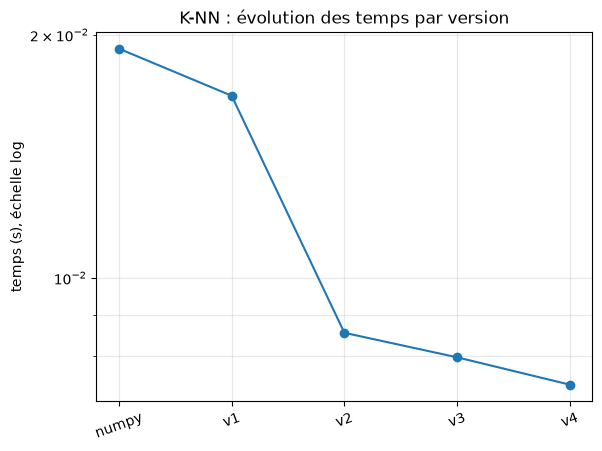

In [47]:
t0 = results['numpy']
print(f"{'version':<16}{'temps (s)':>12}{'accélération':>15}")
for name, t in results.items():
    print(f"{name:<16}{t:>12.4f}{t0 / t:>14.1f}x")

plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.yscale('log')
plt.ylabel('temps (s), échelle log')
plt.title('K-NN : évolution des temps par version')
plt.grid(True, which='both', alpha=0.3)
plt.xticks(rotation=20)
plt.show()

## Analyse des résultats

- **V1** : la compilation seule n'apporte rien, car le code manipule toujours des objets Python.
- **V2** : gros gain, car la boucle de distances n'utilise plus d'objets Python et ne crée plus
  de tableau temporaire.
- **V3** : gain faible (quelques pourcents), un appel de fonction en moins par couple (test, train).
- **V4** : gain faible (quelques pourcents), les vérifications d'indices disparaissent de la boucle interne.

Pour observer les améliorations apportées par V3 et V4 en terme de temps, il faut faire suffisamment de tests pour discerner l'amélioration du simple bruit.

Au final le plus gros de l'accélération s'est fait sur la conversion du calcul des distances en boucle. On pourrait encore plus améiorer les performances en suivant la même logique pour les méthodes argpartition, bincount, argmax à la fin de notre fonction, mais on va s'en passer ici, on a compris le principe.

## <a name="ex3">Exercise 3: Code acceleration with numba</a> [(&#8593;)](#content)

`numba` is a just-in-time (JIT) compiler which translates Python codes into efficient machine code at runtime. A significant acceleration can be obtained by adding a few simple decorators to a standard Python function, up to a few restrictions detailed [here](http://numba.pydata.org/numba-doc/latest/user/performance-tips.html).

If you have written most of the KNN classifier of exercise 1 with numpy, there is little to no chance that you will get an acceleration with numba (justifying the use of cython in this case). An interesting acceleration factor can however be obtained for the computation of the total variation investigated in session 2.

1\. Take a look at the [numba 5 min tour](http://numba.pydata.org/numba-doc/latest/user/5minguide.html), and accelerate the total variation code from session 2 with the `@jit` decorator. You may have to rewrite small portions of your code to get the expected acceleration (see [performance tips](http://numba.pydata.org/numba-doc/latest/user/performance-tips.html)).

**Answer:**

Tout d'abord, nous allons créer deux versions de la fonction en full numpy d'une part et en numpy optimisé d'autre part pour nous servir de référence pour notre benchmark.

In [48]:
import time

# 1ère version : standard en full numpy

def gradient2D(X):
    if X.ndim != 2:
        raise ValueError("Input array must be 2D")

    X_D = np.column_stack((
        X[:, 1:] - X[:, :-1],
        np.zeros(X.shape[0], dtype=X.dtype)
    ))

    D_X = np.vstack((
        X[1:, :] - X[:-1, :],
        np.zeros(X.shape[1], dtype=X.dtype)
    ))

    return X_D, D_X


def tv_numpy(X):
    X_D, D_X = gradient2D(X)
    return np.sum(np.sqrt(X_D**2 + D_X**2))


# 2 : version numpy optimisée (sans vstack ou columnstack)

def tv_numpy_optimized(X):
    n, m = X.shape

    dx = X[:, 1:] - X[:, :-1]
    dy = X[1:, :] - X[:-1, :]

    total = np.sum(
        np.sqrt(
            dx[:-1, :] ** 2 +
            dy[:, :-1] ** 2
        )
    )

    total += np.sum(np.abs(dy[:, -1]))
    total += np.sum(np.abs(dx[-1, :]))

    return total

Maintenant nous allons créer plusieurs versions du programme avec différents niveaux d'accélération possible en NUMBA, pour évaluer de quoi numba est capable.

In [ ]:
from numba import njit, prange

# on teste différentes versions (on détaille ce que fait chaque amélioration dans la section analyse)

# 3. compilation numba
@njit
def tv_numba(X):
    n, m = X.shape
    total = 0.0

    for i in range(n - 1):
        for j in range(m - 1):
            dx = X[i, j + 1] - X[i, j]
            dy = X[i + 1, j] - X[i, j]

            total += np.sqrt(dx * dx + dy * dy)

    j = m - 1
    for i in range(n - 1):
        dy = X[i + 1, j] - X[i, j]
        total += abs(dy)

    i = n - 1
    for j in range(m - 1):
        dx = X[i, j + 1] - X[i, j]
        total += abs(dx)

    return total


# 4. fastmath
@njit(fastmath=True)
def tv_numba_fastmath(X):
    n, m = X.shape
    total = 0.0

    for i in range(n - 1):
        for j in range(m - 1):
            dx = X[i, j + 1] - X[i, j]
            dy = X[i + 1, j] - X[i, j]

            total += np.sqrt(dx * dx + dy * dy)

    j = m - 1
    for i in range(n - 1):
        dy = X[i + 1, j] - X[i, j]
        total += abs(dy)

    i = n - 1
    for j in range(m - 1):
        dx = X[i, j + 1] - X[i, j]
        total += abs(dx)

    return total


# 5. parallel
@njit(parallel=True)
def tv_numba_parallel(X):
    n, m = X.shape
    total = 0.0

    for i in prange(n - 1):
        local = 0.0

        for j in range(m - 1):
            dx = X[i, j + 1] - X[i, j]
            dy = X[i + 1, j] - X[i, j]

            local += np.sqrt(dx * dx + dy * dy)

        total += local

    j = m - 1
    for i in range(n - 1):
        dy = X[i + 1, j] - X[i, j]
        total += abs(dy)

    i = n - 1
    for j in range(m - 1):
        dx = X[i, j + 1] - X[i, j]
        total += abs(dx)

    return total

# 6. parallel + fastmath
@njit(parallel=True, fastmath=True)
def tv_numba_parallel_fastmath(X):
    n, m = X.shape
    total = 0.0

    for i in prange(n - 1):
        local = 0.0

        for j in range(m - 1):
            dx = X[i, j + 1] - X[i, j]
            dy = X[i + 1, j] - X[i, j]

            local += np.sqrt(dx * dx + dy * dy)

        total += local

    j = m - 1
    for i in range(n - 1):
        dy = X[i + 1, j] - X[i, j]
        total += abs(dy)

    i = n - 1
    for j in range(m - 1):
        dx = X[i, j + 1] - X[i, j]
        total += abs(dx)

    return total

2\. Compare the runtime of the your numpy implementation and the `numba`-accelerated version (using `timeit.timeit`). 
> **Warning**: first run the numba version once to trigger the compilation, and then time it as usual. This is needed to avoid including the JIT compilation step in the runtime.

In [ ]:
# Fonction de benchmark

def bench_tv(f, X, n=30):
    # Warm-up : compilation Numba si nécessaire
    result = f(X)

    times = np.empty(n, dtype=np.float64)

    for k in range(n):
        t0 = time.perf_counter()
        result = f(X)
        t1 = time.perf_counter()
        times[k] = t1 - t0

    return (
        np.median(times),
        np.min(times),
        np.max(times),
        result
    )

rng = np.random.default_rng(42)

bench_functions = {
    "numpy": tv_numpy,
    "NumPy optimisé": tv_numpy_optimized,
    "Numba": tv_numba,
    "Numba fastmath": tv_numba_fastmath,
    "Numba parallel": tv_numba_parallel,
    "Numba parallel+fast": tv_numba_parallel_fastmath,
}

# Validation : tous les algorithmes doivent donner le même résultat, et coût de compilation
import numba

print("Threads numba :", numba.get_num_threads())

X0 = rng.uniform(0.0, 10.0, size=(500, 500))
ref_tv = tv_numpy(X0)

print(f"{'version':<22}{'1er appel (ms)':>16}{'écart relatif':>16}")
for name, f in bench_functions.items():
    if hasattr(f, 'recompile'):
        f.recompile() # force la recompilation pour mesurer son coût
    t0 = time.perf_counter(); r = f(X0); t_first = time.perf_counter() - t0
    assert np.isclose(r, ref_tv, rtol=1e-10), f"{name} : résultat incorrect"
    print(f"{name:<22}{t_first*1e3:>16.1f}{abs(r - ref_tv) / ref_tv:>16.1e}")


Threads numba : 18
version                 1er appel (ms)   écart relatif
numpy                              1.6         0.0e+00
NumPy optimisé                     0.7         0.0e+00
Numba                            471.4         1.7e-14
Numba fastmath                    78.8         9.4e-15
Numba parallel                   314.1         3.6e-16
Numba parallel+fast              247.7         1.8e-16


**Answer:**

In [ ]:
# calcul du temps (et du speedup) en fonction de la taille de la matrice en entrée

tailles = [100, 300, 500, 800, 1000, 1500, 2000, 3000, 4000, 6000, 8000, 15000]

# budget mémoire à partir duquel on considère un "out of memory"
MAX_BYTES = 3e9 # 3GB

all_times = {name: [] for name in bench_functions}

for i, N in enumerate(tailles):
    print(f"Test {N} x {N}")

    X = rng.uniform(0.0, 10.0, size=(N, N))
    n_rep = 50 if N <= 500 else 20 if N <= 1500 else 10 if N <= 3000 else 5

    for name, func in bench_functions.items():
        if name.startswith("numpy") and 6 * 8 * N**2 > MAX_BYTES:
            all_times[name].append(np.nan)
            continue
        median, best, worst, result = bench_tv(func, X, n=n_rep)
        all_times[name].append(median * 1000)

print("terminé")

Test 100 x 100
Test 300 x 300
Test 500 x 500
Test 800 x 800
Test 1000 x 1000
Test 1500 x 1500
Test 2000 x 2000
Test 3000 x 3000
Test 4000 x 4000
Test 6000 x 6000
Test 8000 x 8000
Test 15000 x 15000
terminé


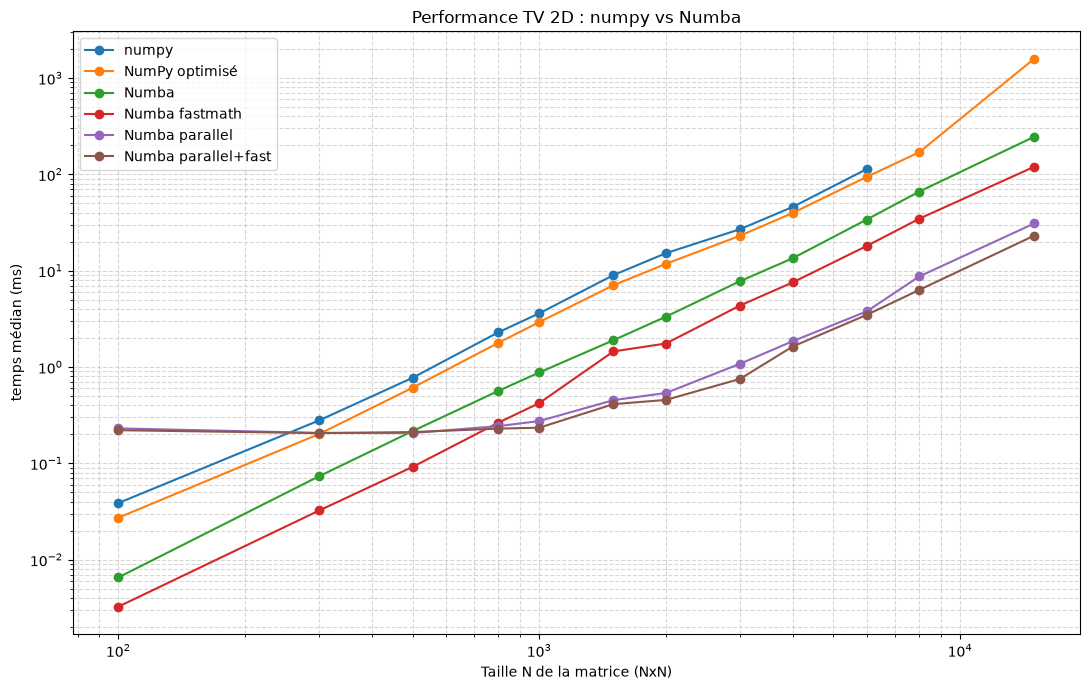

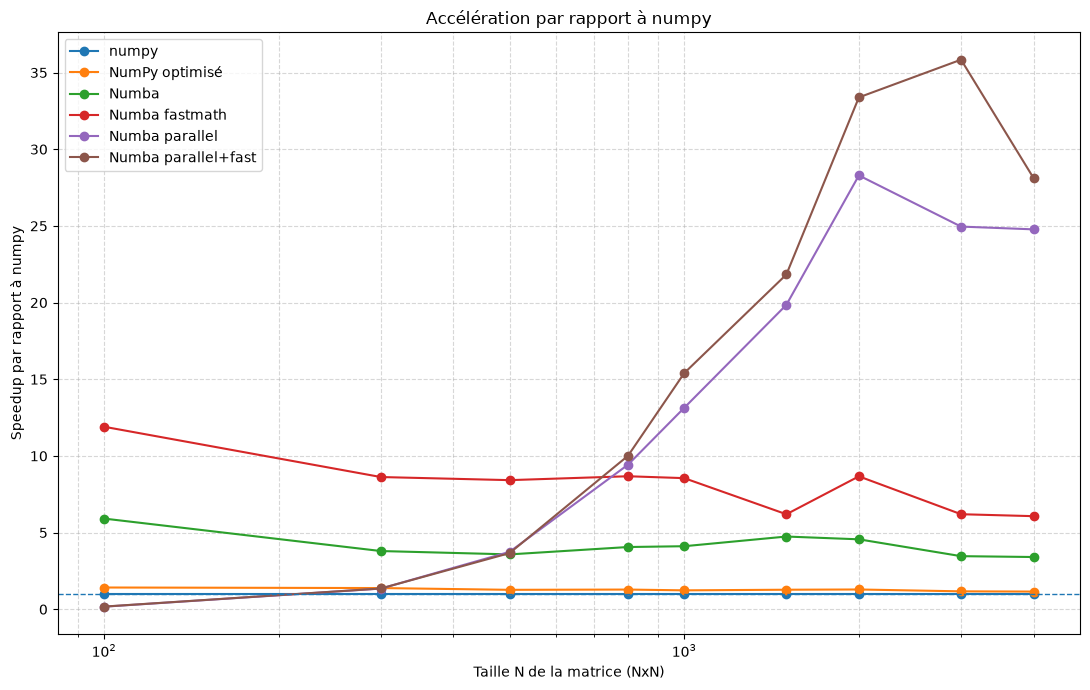

In [52]:
# graphique des temps

plt.figure(figsize=(11, 7))

for name, times in all_times.items():
    plt.loglog(tailles,times,"o-",label=name)

plt.xlabel("Taille N de la matrice (NxN)")
plt.ylabel("temps médian (ms)")
plt.title("Performance TV 2D : numpy vs Numba")

plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.legend()
plt.tight_layout()
plt.show()

# graphique des speedups

numpy_times = np.array(all_times["numpy"])

n_plot = np.flatnonzero(~np.isnan(numpy_times))[-1] # on exclue la derrière mesure car elle est trop bruitée

plt.figure(figsize=(11, 7))

for name, times in all_times.items():
    times = np.array(times)
    speedup = numpy_times / times

    plt.semilogx(tailles[:n_plot], speedup[:n_plot], "o-", label=name)

plt.axhline(1.0, linestyle="--", linewidth=1)

plt.xlabel("Taille N de la matrice (NxN)")
plt.ylabel("Speedup par rapport à numpy")
plt.title("Accélération par rapport à numpy")

plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.legend()
plt.tight_layout()
plt.show()

In [54]:
#tableau numérique final
print()
print("=" * 70)
print("RÉSUMÉ")
print("=" * 70)

header = (
    f"{'N':>6} | "
    f"{'NumPy':>12} | "
    f"{'NumPy opt':>12} | "
    f"{'Numba':>12} | "
    f"{'Fastmath':>12} | "
    f"{'Parallel':>12} | "
    f"{'Par+Fast':>12}"
)

print(header)
print("-" * len(header))

for k, N in enumerate(tailles):
    row = (
        f"{N:6d} | "
        f"{all_times['numpy'][k]:12.3f} | "
        f"{all_times['NumPy optimisé'][k]:12.3f} | "
        f"{all_times['Numba'][k]:12.3f} | "
        f"{all_times['Numba fastmath'][k]:12.3f} | "
        f"{all_times['Numba parallel'][k]:12.3f} | "
        f"{all_times['Numba parallel+fast'][k]:12.3f}"
    )

    print(row)


RÉSUMÉ
     N |        NumPy |    NumPy opt |        Numba |     Fastmath |     Parallel |     Par+Fast
------------------------------------------------------------------------------------------------
   100 |        0.039 |        0.027 |        0.007 |        0.003 |        0.230 |        0.221
   300 |        0.279 |        0.202 |        0.074 |        0.032 |        0.207 |        0.206
   500 |        0.773 |        0.609 |        0.216 |        0.092 |        0.206 |        0.211
   800 |        2.295 |        1.785 |        0.565 |        0.265 |        0.243 |        0.229
  1000 |        3.608 |        2.923 |        0.877 |        0.422 |        0.275 |        0.234
  1500 |        8.985 |        7.049 |        1.894 |        1.450 |        0.453 |        0.412
  2000 |       15.202 |       11.782 |        3.332 |        1.754 |        0.537 |        0.455
  3000 |       26.960 |       23.058 |        7.784 |        4.349 |        1.080 |        0.752
  4000 |       45.855 


## Analyse

Tout d'abord, on note que toutes les versions produisent le même résultat numérique.

Après recherche dans la documentation de Numba et analyse de nos résultats :

-le décorateur @njit permet de compiler/fuser la boucle de la fonction en une seule passe (on se passe des surcoûts liés à la création des talbeaux, plusieurs appels de fonctions etc. on évite l'interpréteur). Globalement, le gain par rapport à numpy est de x3.

-fastmath=True : dans l'accumulation `total += ...`, l'addition des flottants est non associative. donc pour garantir des résultats cohérents, le comportement de base force l'ajout séquentiel. fastmath=True permet de contourner cela, et au prix d'une petite différence numérique (très faible ici), de vectoriser la boucle. Dans notre cas, cela améliore x2 par rapport à la version Numba simple.

-parallel=True : permet la parallélisation des boucles sur plusieurs coeurs. Ici, à partir d'une taille de matrice assez grande (1000x1000), elle dépasse largement la version de base de Numba avec une accélération de x25. On note que pour des matrices petites, cette version n'est pas "rentable" car le temps passé pour la compilation ne vaut pas le coup.

-fastmath=True et parallel=True : on combine les 2 précédentes versions et on obtient les meilleurs gains.

Enfin, on note également que la version numpy utilise beaucoup plus de mémoire que les versions compilées.